# Dropouts (Regression)

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from mlxtend.plotting import plot_decision_regions
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

In [68]:
from sklearn.datasets import fetch_california_housing

In [69]:
X, y = fetch_california_housing(return_X_y = True)

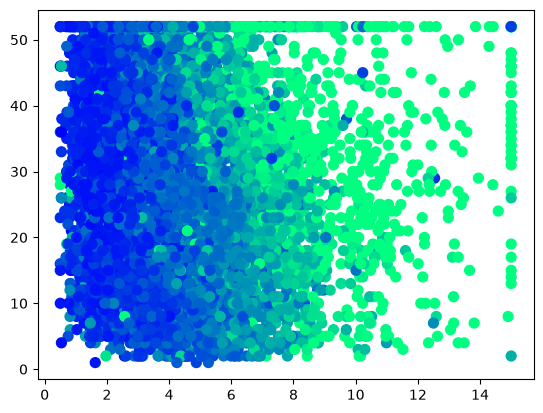

In [70]:
plt.scatter(X[:,0],X[:,1], c = y, cmap = 'winter',s = 50)
plt.show()

In [71]:
X

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

In [72]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [74]:
X_train,X_test,y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [75]:
scaler = StandardScaler()

In [76]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
model = Sequential()

In [78]:
model.add(Dense(140, activation = 'relu',input_dim = 8))
model.add(Dropout(0.25))
model.add(Dense(140, activation = 'relu'))
model.add(Dropout(0.25))
model.add(Dense(80, activation= 'relu'))
model.add(Dropout(0.25))
model.add(Dense(1, activation = 'linear'))

d:\DeepLearning.py\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [79]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 140)            │         1,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 140)            │        19,740 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 80)             │        11,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,361 (126.41 KB)

 Trainable params: 32,361 (126.41 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
callback = EarlyStopping(
    monitor = 'val_loss',
    min_delta = 0.000000001,
    patience = 30,
    baseline = None, 
    mode = 'auto',
    verbose = 1,
    restore_best_weights = True
)

In [81]:
from keras.metrics import R2Score

adam = Adam(learning_rate = 0.001)
model.compile(loss = 'mse',optimizer = adam, metrics = [R2Score()])
history = model.fit(X_train_scaled, y_train, epochs = 1000, callbacks = callback,verbose = 1, validation_split = 0.2, batch_size = 40)

Epoch 1/1000
331/331 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.8846 - r2_score: 0.3348 - val_loss: 0.4806 - val_r2_score: 0.6478
Epoch 2/1000
331/331 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.5387 - r2_score: 0.5949 - val_loss: 0.4226 - val_r2_score: 0.6903
Epoch 3/1000
331/331 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.4809 - r2_score: 0.6383 - val_loss: 0.4293 - val_r2_score: 0.6854
Epoch 4/1000
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4622 - r2_score: 0.6524 - val_loss: 0.3933 - val_r2_score: 0.7118
Epoch 5/1000
331/331 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4477 - r2_score: 0.6633 - val_loss: 0.4288 - val_r2_score: 0.6858
Epoch 6/1000
331/331 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.4198 - r2_score: 0.6843 - val_loss: 0.3637 - val_r2_score: 0.7335
Epoch 7/1000
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3988 - r2_score: 0.7001 - val_loss: 0.4164 - val_r2_score: 0.6948
Epoch 8/1000
331/331 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3947 - r2_score: 0.7032 - 

In [82]:
y_pred = model.predict(X_test_scaled)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [83]:
from sklearn.metrics import r2_score

In [84]:
r2_score(y_test, y_pred)

0.8044768097874938